In [ ]:
#================================================================================
#
# Name: machine-learning-sarimax-gdp.ipynb
#
# Description: This notebook contains an analysis of GDP data using SARIMAX
#              models to forecast future GDP values.
# Author: MT
# 
# Date: 2025-11-15
# 
# Steps:
# Step 0: Import Libraries
# Step 1: Read Data
# Step 2: Prepare Data
# Step 7: Results
# 
#================================================================================

In [ ]:
#================================================================================
# Step 0: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pmdarima import auto_arima

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import copy
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
#================================================================================

In [ ]:
#================================================================================
# Step 1: Read Data
df = pd.read_csv('series-060425b.csv')
df.info()
#================================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Quarter  280 non-null    object
 1   Level    280 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.5+ KB


In [3]:
# Create a deep copy of the original dataframe to avoid modifying it directly
df2 = copy.deepcopy(df)

# Extract the year from the 'Quarter' column
df2['Y'] = df2['Quarter'].str[:4]

# Extract the quarter number, convert it to the corresponding month, and cast it to string
df2['M'] = (df2['Quarter'].str[-1].astype(int) * 3).astype('str')

# Combine the year and month into a single string and convert it to a datetime object
df2['date'] = df2['Y'] + '-' + df2['M'] + '-01'
df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d') + pd.offsets.MonthEnd(0)

# Convert the datetime object to a date object
df2['date'] = df2['date'].dt.date

# Keep only the 'date' and 'Level' columns
df2 = df2[['date', 'Level']]

# Calculate the year-over-year growth rate (percentage change over 4 quarters)
df2['Growth'] = df2['Level'].pct_change(4)*100

# Drop the first 4 rows with NaN values in the 'Growth' column
mask = df2['date'] >= pd.Timestamp('1975-01-01').date()
df2 = df2[mask]

# Drop covid impact
#mask = df2['date'] <= pd.Timestamp('2019-12-31').date()
#df2 = df2[mask]

df2.reset_index(drop=True, inplace=True)

# Display the resulting dataframe
df2

,date,Level,Growth
0,1975-03-31,239702,0.580315
1,1975-06-30,235807,-2.459132
2,1975-09-30,235105,-3.327344
3,1975-12-31,237747,-0.778342
4,1976-03-31,241709,0.837290
...,...,...,...
195,2023-12-31,632365,-0.264808
196,2024-03-31,637729,0.460297
197,2024-06-30,640592,0.901923
198,2024-09-30,640417,1.003861


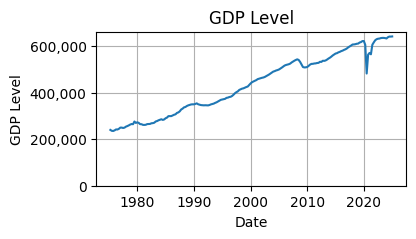

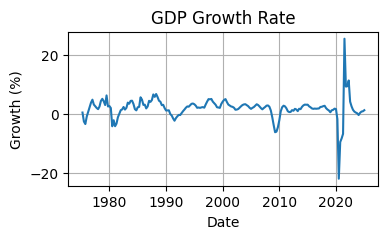

In [4]:
# Plot the GDP Level over time
plt.figure(figsize=(4, 2))
sns.lineplot(x='date', y='Level', data=df2)
plt.title('GDP Level')
plt.xlabel('Date')
plt.ylabel('GDP Level')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylim(bottom=0)
plt.grid(True) 
plt.show()

# Plot the GDP Growth Rate over time
plt.figure(figsize=(4, 2))
sns.lineplot(x='date', y='Growth', data=df2)
plt.title('GDP Growth Rate')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.grid(True) 
plt.show()

In [5]:
# Test stationarity using ADF test
# H0: The time series is non-stationary
# H1: The time series is stationary

# Perform the ADF test on the 'Level' column
result = adfuller(df2['Level'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print('Do not Rej H0, time series is not stationary')
print('')

# Perform the ADF test on the 'Growth' column
result = adfuller(df2['Growth'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print('Rej H0, time series is stationary')

ADF Statistic: -0.23134754863055268
p-value: 0.9346804554497686
Do not Rej H0, time series is not stationary

ADF Statistic: -4.141210959912671
p-value: 0.000827277183840798
Rej H0, time series is stationary


<Figure size 400x200 with 0 Axes>

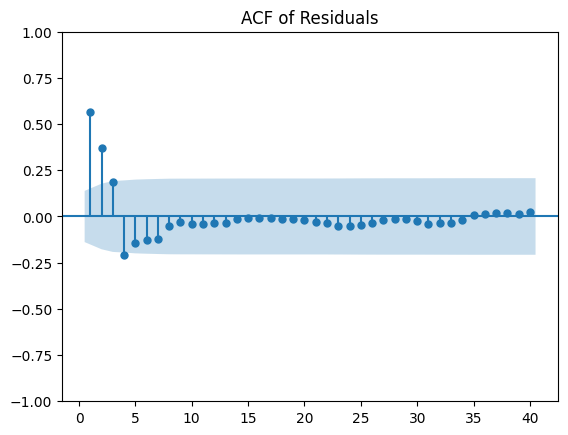

<Figure size 400x200 with 0 Axes>

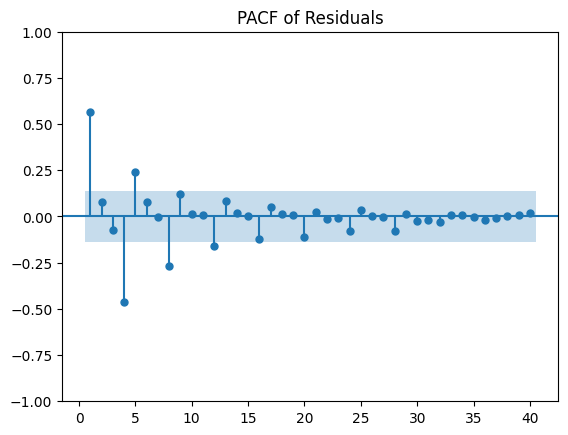

In [6]:
# ACF and PACF on the Growth Rate
residuals=df2['Growth'] 

# Plot the ACF
plt.figure(figsize=(4, 2))
plot_acf(residuals, lags=40, title="ACF of Residuals", zero=False)
plt.show()

# Plot the PACF
plt.figure(figsize=(4, 2))
plot_pacf(residuals, lags=40, title="PACF of Residuals", zero=False)
plt.show()

In [7]:
# Copy data
df3=copy.deepcopy(df2[['date','Growth']])
df3.set_index('date', inplace=True)
df3.index = pd.to_datetime(df3.index)  # Ensure the index is a datetime index
df3 = df3.asfreq('QE')

                                     SARIMAX Results                                      
Dep. Variable:                             Growth   No. Observations:                  200
Model:             SARIMAX(1, 0, 1)x(2, 0, [], 4)   Log Likelihood                -443.514
Date:                            Thu, 17 Apr 2025   AIC                            899.028
Time:                                    20:41:20   BIC                            918.542
Sample:                                03-31-1975   HQIC                           906.932
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6534      0.238      2.743      0.006       0.187       1.120
ar.L1          0.8410      0.073   

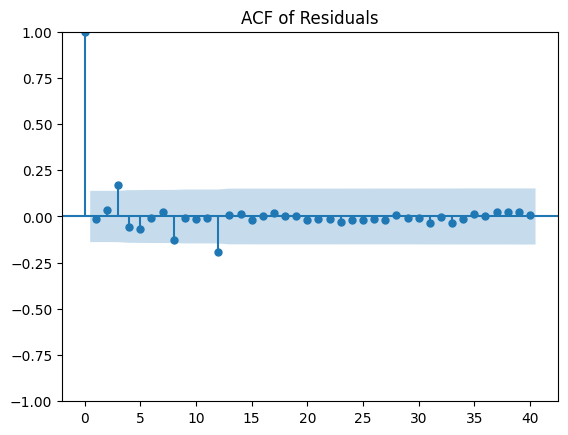

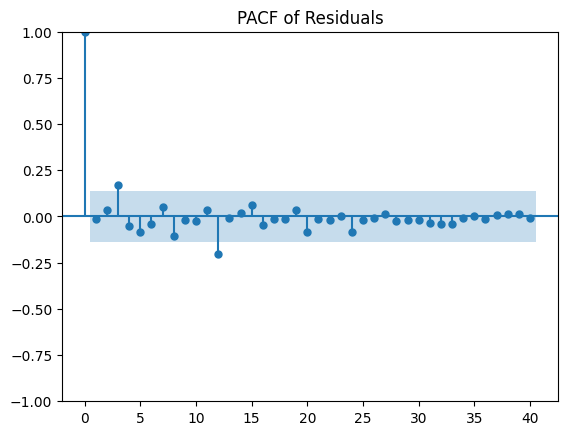

Ljung-Box Test Results:
     lb_stat  lb_pvalue
12  19.34482    0.08054


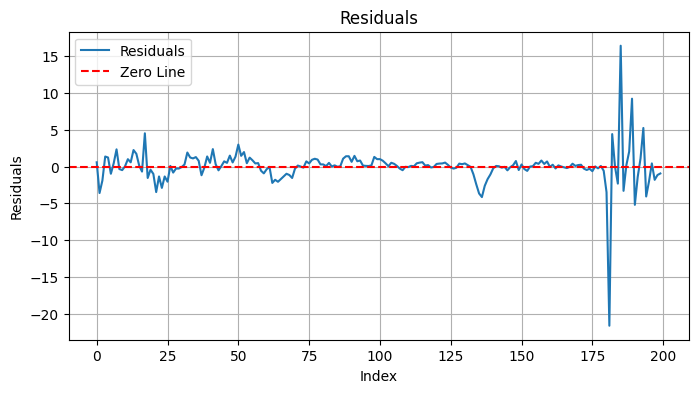

In [8]:
model = SARIMAX(df3['Growth'], 
                order=(1, 0, 1),  # Non-seasonal ARIMA(p, d, q)
                seasonal_order=(2, 0, 0, 4),  # Seasonal ARIMA(P, D, Q, s)
                enforce_stationarity=False, 
                enforce_invertibility=False, 
                trend='c')  # Include intercept

# Fit the model
fitted_model = model.fit()

# Print the summary of the fitted model
print(fitted_model.summary())

# Get in-sample predictions
residuals = fitted_model.resid

# Get in-sample predictions
predicted_values = fitted_model.predict()

# Plot ACF and PACF of residuals
plot_acf(residuals, lags=40, title="ACF of Residuals")
plt.show()
plot_pacf(residuals, lags=40, title="PACF of Residuals")
plt.show()

# Perform Ljung-Box test
ljung_box_results = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("Ljung-Box Test Results:")
print(ljung_box_results)

# Plot residuals using Seaborn
plt.figure(figsize=(8, 4))
sns.lineplot(x=range(len(residuals)), y=residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.title("Residuals")
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.legend()
plt.grid(True)
plt.show()


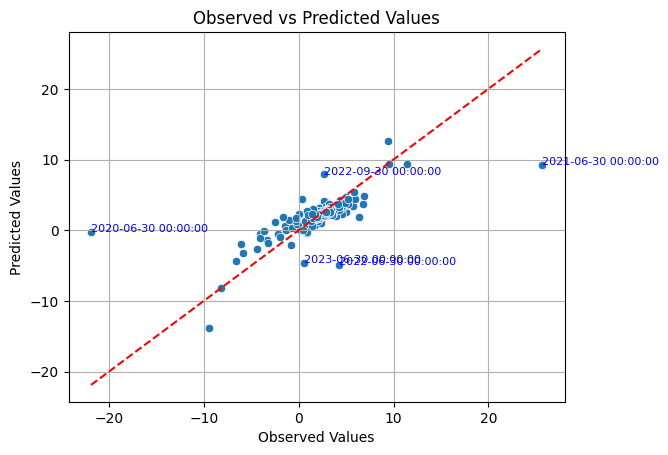

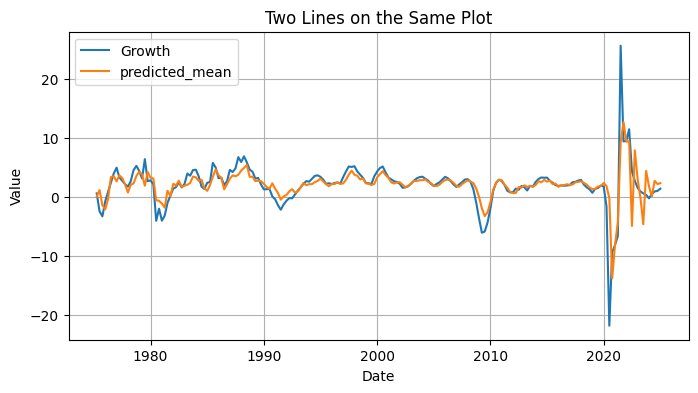

In [9]:
temp=pd.merge(left=df3.reset_index(), 
              right=pd.DataFrame(predicted_values).reset_index(),
              how='inner',
              left_on='date',
              right_on='date')

temp2=pd.merge(left=temp,
                right=pd.DataFrame(residuals).reset_index(),
                how='inner',
                left_on='date',
                right_on='date')
temp2.rename(columns={0:'Residuals'}, inplace=True)
temp2['q']=temp2['Growth']-temp2['predicted_mean']

sns.scatterplot(data=temp2, x='Growth', y='predicted_mean')
plt.xlabel('Observed Values')
plt.ylabel('Predicted Values')
plt.title('Observed vs Predicted Values')

# Add a 45-degree line
min_val = min(temp2['Growth'].min(), temp2['predicted_mean'].min())
max_val = max(temp2['Growth'].max(), temp2['predicted_mean'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='45-degree line')

## Add data labels for specific points
#for i, row in temp2.iterrows():
#    if row['Growth'] > 8 or row['Growth'] <- 8:
#        plt.text(row['Growth'], row['predicted_mean'], 
#                 f"{row['date']}",  # Display the date
#                 fontsize=8, color='blue')

# Add data labels for specific points
for i, row in temp2.iterrows():
    if row['Residuals'] > 5 or row['Residuals'] <-5:
        plt.text(row['Growth'], row['predicted_mean'], 
                 f"{row['date']}",  # Display the date
                 fontsize=8, color='blue')

plt.grid(True)
plt.show()

# Plot using Seaborn
plt.figure(figsize=(8, 4))
sns.lineplot(x='date', y='Growth', data=temp2, label='Growth')
sns.lineplot(x='date', y='predicted_mean', data=temp2, label='predicted_mean')
plt.title('Two Lines on the Same Plot')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\markt\AppData\Local\Temp\ipykernel_17960\158345510.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=df3.index[-1], periods=forecast_steps + 1, freq='Q')[1:]


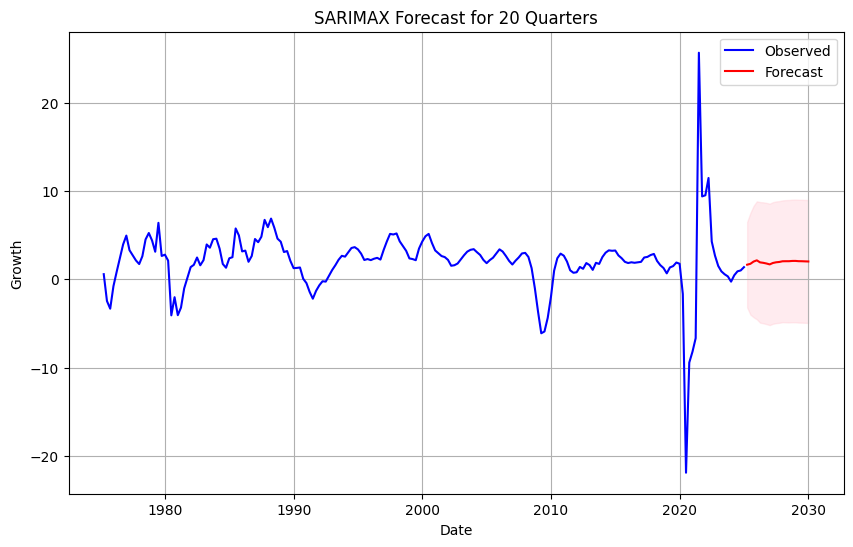

,Forecast,Lower Bound,Upper Bound
2025-03-31,1.651717,-3.183577,6.487011
2025-06-30,1.751586,-3.991932,7.495105
2025-09-30,2.007305,-4.300068,8.314679
2025-12-31,2.147415,-4.530048,8.824878
2026-03-31,1.918714,-4.906950,8.744378
2026-06-30,1.866473,-4.980384,8.713330
2026-09-30,1.788579,-5.073227,8.650385
2026-12-31,1.686733,-5.185626,8.559091
2027-03-31,1.845764,-5.038705,8.730234
2027-06-30,1.925213,-4.962093,8.812519


In [ ]:
# Forecast the next 20 quarters
forecast_steps = 20
forecast = fitted_model.get_forecast(steps=forecast_steps)

# Get confidence intervals for the forecast
conf_int = forecast.conf_int()

# Create a DataFrame for the forecasted values
forecast_index = pd.date_range(start=df3.index[-1], periods=forecast_steps + 1, freq='Q')[1:]
forecast_df = pd.DataFrame({
    'Forecast': forecast.predicted_mean,
    'Lower Bound': conf_int.iloc[:, 0],
    'Upper Bound': conf_int.iloc[:, 1]
}, index=forecast_index)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(df3.index, df3['Growth'], label='Observed', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['Lower Bound'], forecast_df['Upper Bound'], color='pink', alpha=0.3)
plt.title('SARIMAX Forecast')
plt.xlabel('Date')
plt.ylabel('Growth')
plt.legend()
plt.grid(True)
plt.show()

display(forecast_df)